# Lucas do Rio Verde (MT): projeção populacional e demanda habitacional, 2026–2035

**Autora:** Thamires Martins da Silva  
**Fonte dos dados:** IBGE — SIDRA (tabela 6579) e Censos Demográficos 2010 e 2022  
**Ferramentas:** Python (pandas, matplotlib, scikit-learn)

---

## Contexto

Lucas do Rio Verde saiu de 6.693 habitantes em 1991 para 95.792 em 2025 — crescimento superior a 1.100% em três décadas. Em 2025 foi o município que mais cresceu no Centro-Oeste e o segundo do Brasil entre cidades com mais de 50 mil habitantes. O motor é a agroindústria, que atrai trabalhadores de outras regiões de forma sustentada.

Esse ritmo pressiona diretamente o mercado imobiliário local, mas o setor opera sem uma quantificação pública de quanta moradia a cidade precisará nos próximos anos.

## Pergunta de negócio

**Se Lucas do Rio Verde mantiver seu ritmo de crescimento, quantos novos moradores chegam por ano até 2035, e quantas unidades habitacionais serão necessárias para abrigá-los?**

## Estrutura da análise

1. Extração da série populacional via API do SIDRA
2. Tratamento, verificação de qualidade e consolidação com dados censitários
3. Cálculo de taxas de crescimento por período (CAGR)
4. Construção de três cenários de projeção até 2035
5. Conversão de população em demanda habitacional, com análise de sensibilidade
6. Modelagem estatística e validação temporal
7. Limitações e sumário executivo

## 1. Configuração do ambiente

Definição dos caminhos do projeto e do código do município no IBGE.

In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --- Configuração do projeto ---
base = Path.home() / 'portfolio-dados' / 'lucas-do-rio-verde'
(base / 'dados').mkdir(parents=True, exist_ok=True)

COD_MUNICIPIO = 5105259  # Lucas do Rio Verde (MT) — IBGE

print(f'Pasta do projeto: {base}')
print(f'Pasta de dados existe: {(base / "dados").exists()}')

Pasta do projeto: C:\Users\greyt\portfolio-dados\lucas-do-rio-verde
Pasta de dados existe: True


## 2. Extração dos dados

A população é obtida diretamente da API do SIDRA/IBGE (tabela 6579 — População residente estimada), sem download manual de arquivos. Isso torna a análise reprodutível: qualquer pessoa que rode o notebook obtém os mesmos dados atualizados na fonte.

A inspeção do JSON bruto vem antes de qualquer tratamento — a API do SIDRA devolve o primeiro registro como cabeçalho descritivo, e não como observação. Ignorar esse detalhe corromperia a série.

In [2]:
# Tabela 6579 — População residente estimada | v/9324 = população | p/all = todos os anos
url = f'https://apisidra.ibge.gov.br/values/t/6579/n6/{COD_MUNICIPIO}/v/9324/p/all'

try:
    resposta = requests.get(url, timeout=30)
    resposta.raise_for_status()
    bruto = resposta.json()
    print(f'Requisição OK — {len(bruto)} registros retornados\n')
except requests.exceptions.RequestException as e:
    print(f'Falha na requisição: {e}')
    bruto = None

# Inspeção do dado bruto antes de qualquer tratamento
if bruto:
    print('Primeiro registro (cabeçalho descritivo da API):')
    for chave, valor in bruto[0].items():
        print(f'  {chave}: {valor}')
    print('\nSegundo registro (primeira observação real):')
    for chave, valor in bruto[1].items():
        print(f'  {chave}: {valor}')

Requisição OK — 22 registros retornados

Primeiro registro (cabeçalho descritivo da API):
  NC: Nível Territorial (Código)
  NN: Nível Territorial
  MC: Unidade de Medida (Código)
  MN: Unidade de Medida
  V: Valor
  D1C: Município (Código)
  D1N: Município
  D2C: Variável (Código)
  D2N: Variável
  D3C: Ano (Código)
  D3N: Ano

Segundo registro (primeira observação real):
  NC: 6
  NN: Município
  MC: 45
  MN: Pessoas
  V: 20873
  D1C: 5105259
  D1N: Lucas do Rio Verde (MT)
  D2C: 9324
  D2N: População residente estimada
  D3C: 2001
  D3N: 2001


## 3. Tratamento e verificação de qualidade

A API devolve todos os campos como texto, incluindo ano e população. A conversão de tipos vem acompanhada de verificações explícitas: valores nulos, anos duplicados e cobertura temporal.

A comparação entre anos esperados e anos presentes antecipa o problema tratado na seção seguinte.

In [3]:
# --- Limpeza do dado bruto do SIDRA ---

# 1. Remove o cabeçalho descritivo (primeiro elemento não é observação)
df_sidra = pd.DataFrame(bruto[1:])
print(f'Registros após remoção do cabeçalho: {len(df_sidra)}')

# 2. Seleciona e renomeia as colunas de interesse
df_sidra = df_sidra[['D3N', 'V', 'D1N', 'MN']].copy()
df_sidra.columns = ['ano', 'populacao', 'municipio', 'unidade']

# 3. Converte tipos (a API devolve tudo como texto)
df_sidra['ano'] = pd.to_numeric(df_sidra['ano'], errors='coerce')
df_sidra['populacao'] = pd.to_numeric(df_sidra['populacao'], errors='coerce')

# 4. Verificações de qualidade
print('\n--- Qualidade dos dados ---')
print(f'Valores nulos:\n{df_sidra.isna().sum()}')
print(f'\nAnos duplicados: {df_sidra["ano"].duplicated().sum()}')
print(f'Intervalo: {df_sidra["ano"].min()} a {df_sidra["ano"].max()}')
print(f'Anos esperados: {df_sidra["ano"].max() - df_sidra["ano"].min() + 1}')
print(f'Anos presentes: {df_sidra["ano"].nunique()}')

# 5. Ordena e finaliza
df_sidra = df_sidra.sort_values('ano').reset_index(drop=True)

print('\n--- Série tratada ---')
print(df_sidra[['ano', 'populacao']].to_string(index=False))

Registros após remoção do cabeçalho: 21

--- Qualidade dos dados ---
Valores nulos:
ano          0
populacao    0
municipio    0
unidade      0
dtype: int64

Anos duplicados: 0
Intervalo: 2001 a 2025
Anos esperados: 25
Anos presentes: 21

--- Série tratada ---
 ano  populacao
2001      20873
2002      21972
2003      23205
2004      25792
2005      27224
2006      28646
2008      32255
2009      33556
2011      47571
2012      49519
2013      52843
2014      55094
2015      57285
2016      59436
2017      61515
2018      63411
2019      65534
2020      67620
2021      69671
2024      92256
2025      95792


## 4. Lacunas na série

A tabela 6579 cobre 2001–2025, mas com 21 observações para um intervalo de 25 anos. Identificar exatamente quais anos faltam — e por quê — é pré-requisito para qualquer cálculo de taxa.

In [4]:
# --- Identificação das lacunas na série ---
anos_esperados = set(range(int(df_sidra['ano'].min()), int(df_sidra['ano'].max()) + 1))
anos_presentes = set(df_sidra['ano'].astype(int))
faltantes = sorted(anos_esperados - anos_presentes)

print('Anos ausentes na série:', faltantes)

Anos ausentes na série: [2007, 2010, 2022, 2023]


### Por que esses anos faltam

Nenhuma das quatro ausências é falha de extração:

- **2010 e 2022** são anos censitários. O IBGE publica contagem direta em tabelas próprias, separadas da série de estimativas.
- **2007** corresponde à Contagem da População, operação distinta do Censo e também publicada à parte.
- **2023** não teve estimativa divulgada.

Os dois anos censitários são incorporados manualmente à série, identificados pela coluna `origem`. 2007 e 2023 permanecem ausentes — preencher por interpolação inventaria dado que o IBGE não produziu.

## 5. Consolidação da série

In [5]:
# --- Consolidação: série SIDRA + anos censitários ---

# Valores dos anos ausentes (fonte: Censos Demográficos IBGE)
censos = pd.DataFrame({
    'ano':       [2010, 2022],
    'populacao': [45545, 83798],
    'origem':    ['censo', 'censo']
})
# 2007 (Contagem) e 2023 (sem divulgação) permanecem ausentes

serie = df_sidra[['ano', 'populacao']].copy()
serie['origem'] = 'estimativa'

serie = pd.concat([serie, censos], ignore_index=True)
serie = serie.sort_values('ano').reset_index(drop=True)

print(f'Série consolidada: {len(serie)} observações ({serie["ano"].min()}-{serie["ano"].max()})')
print(serie['origem'].value_counts().to_string())

# Variação anual — evidencia os rebaseamentos
serie['var_abs'] = serie['populacao'].diff()
serie['var_pct'] = (serie['populacao'].pct_change() * 100).round(2)

print('\n', serie.to_string(index=False))

# Salva a série tratada
serie.to_csv(base / 'dados' / 'populacao_lucas_do_rio_verde.csv', index=False)
print('\nArquivo salvo em dados/populacao_lucas_do_rio_verde.csv')

Série consolidada: 23 observações (2001-2025)
origem
estimativa    21
censo          2

  ano  populacao     origem  var_abs  var_pct
2001      20873 estimativa      NaN      NaN
2002      21972 estimativa   1099.0     5.27
2003      23205 estimativa   1233.0     5.61
2004      25792 estimativa   2587.0    11.15
2005      27224 estimativa   1432.0     5.55
2006      28646 estimativa   1422.0     5.22
2008      32255 estimativa   3609.0    12.60
2009      33556 estimativa   1301.0     4.03
2010      45545      censo  11989.0    35.73
2011      47571 estimativa   2026.0     4.45
2012      49519 estimativa   1948.0     4.09
2013      52843 estimativa   3324.0     6.71
2014      55094 estimativa   2251.0     4.26
2015      57285 estimativa   2191.0     3.98
2016      59436 estimativa   2151.0     3.75
2017      61515 estimativa   2079.0     3.50
2018      63411 estimativa   1896.0     3.08
2019      65534 estimativa   2123.0     3.35
2020      67620 estimativa   2086.0     3.18
2021      6

### Leitura: o padrão de rebaseamento

A coluna `var_pct` revela o comportamento central da série. Nos anos normais a variação fica entre 3% e 5%. Nos dois anos censitários ela salta: **+35,73% em 2010** e **+20,28% em 2022**.

Esses saltos não são aceleração populacional. São **rebaseamentos** — a correção, de uma só vez, da defasagem acumulada pelas estimativas intercensais. O método de estimativa do IBGE tende a subestimar municípios de crescimento migratório acelerado, e o erro só é corrigido quando há contagem direta.

O padrão se repete de forma independente em dois censos distintos, o que confirma a interpretação em vez de sugerir anomalia pontual.

⚠️ **Implicação para o cálculo de taxas:** como 2023 está ausente, a variação registrada em 2024 (+10,09%) cobre um intervalo de dois anos, não de um. Qualquer comparação de ritmo precisa normalizar pelo tempo decorrido — procedimento adotado no cálculo do CAGR.

## 6. A série completa

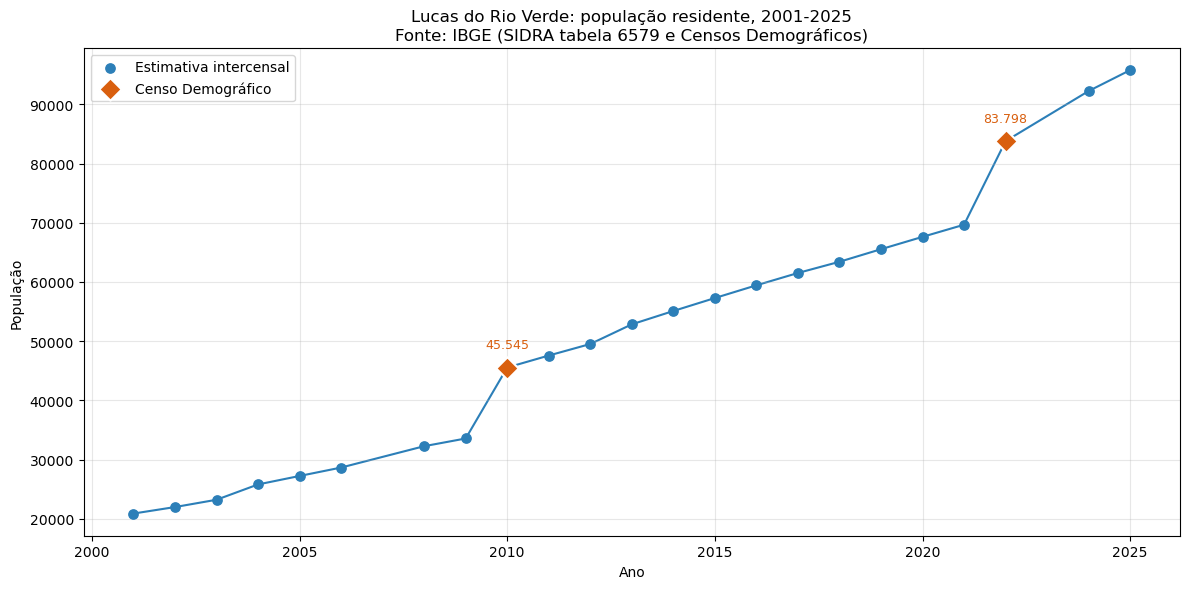

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

est = serie[serie['origem'] == 'estimativa']
cen = serie[serie['origem'] == 'censo']

ax.plot(serie['ano'], serie['populacao'], linewidth=1.5, color='#2c7fb8', zorder=1)
ax.scatter(est['ano'], est['populacao'], s=45, color='#2c7fb8',
           label='Estimativa intercensal', zorder=2)
ax.scatter(cen['ano'], cen['populacao'], s=130, color='#d95f0e', marker='D',
           edgecolor='white', linewidth=1.5, label='Censo Demográfico', zorder=3)

for _, r in cen.iterrows():
    ax.annotate(f'{int(r["populacao"]):,}'.replace(',', '.'),
                (r['ano'], r['populacao']), textcoords='offset points',
                xytext=(0, 14), ha='center', fontsize=9, color='#d95f0e')

ax.set_title('Lucas do Rio Verde: população residente, 2001-2025\nFonte: IBGE (SIDRA tabela 6579 e Censos Demográficos)')
ax.set_xlabel('Ano')
ax.set_ylabel('População')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Leitura do gráfico

Os losangos laranja marcam os dois anos censitários (45.545 em 2010; 83.798 em 2022). Os círculos azuis são estimativas anuais. A trajetória é de crescimento sustentado, sem quebra de tendência — o que muda nos anos censitários é o nível, não a direção.

⚠️ **Artefato visual:** o segmento entre 2022 e 2024 é uma reta única porque 2023 está ausente. A linha atravessa o vazio; ela não representa dado observado nesse trecho.

## 7. Ritmo de crescimento (CAGR)

O CAGR (Compound Annual Growth Rate) normaliza o crescimento pelo tempo decorrido, o que resolve o problema do intervalo de 2 anos em 2024. Calculá-lo por sub-período — em vez de um número único — expõe onde a mudança de metodologia contamina a taxa.

In [7]:
# --- Taxa de crescimento anual composta (CAGR) por período ---

def cagr(pop_inicial, pop_final, anos):
    return ((pop_final / pop_inicial) ** (1 / anos) - 1) * 100

periodos = [
    ('2001-2010 (pré-censo 2010)', 2001, 2010),
    ('2011-2021 (intercensal)',    2011, 2021),
    ('2011-2022 (até censo)',      2011, 2022),
    ('2022-2025 (pós-censo)',      2022, 2025),
    ('2001-2025 (série completa)', 2001, 2025),
]

linhas = []
for rotulo, a_ini, a_fim in periodos:
    p_ini = serie.loc[serie['ano'] == a_ini, 'populacao'].iloc[0]
    p_fim = serie.loc[serie['ano'] == a_fim, 'populacao'].iloc[0]
    n = a_fim - a_ini
    linhas.append({
        'periodo': rotulo,
        'pop_inicial': p_ini,
        'pop_final': p_fim,
        'anos': n,
        'cagr_%': round(cagr(p_ini, p_fim, n), 2)
    })

tab_cagr = pd.DataFrame(linhas)
print(tab_cagr.to_string(index=False))

                   periodo  pop_inicial  pop_final  anos  cagr_%
2001-2010 (pré-censo 2010)        20873      45545     9    9.06
   2011-2021 (intercensal)        47571      69671    10    3.89
     2011-2022 (até censo)        47571      83798    11    5.28
     2022-2025 (pós-censo)        83798      95792     3    4.56
2001-2025 (série completa)        20873      95792    24    6.55


### Qual taxa usar

Cada período conta uma história diferente:

| Período | CAGR | Problema |
|---|---|---|
| 2001–2010 | 9,06% | Termina em censo → inflado pelo rebaseamento |
| **2011–2021** | **3,89%** | **Intercensal puro — mesma metodologia do início ao fim** |
| 2011–2022 | 5,28% | Termina em censo → inflado |
| 2022–2025 | 4,56% | Mistura pós-censo com estimativa |
| 2001–2025 | 6,55% | Atravessa duas mudanças de método |

O período **2011–2021** é o único livre de contaminação: começa e termina em anos de estimativa, sob a mesma metodologia. Por isso ele ancora o cenário Base. Os demais servem de piso e teto plausíveis.

## 8. Cenários de projeção

Três cenários projetam a população até 2035, cada um ancorado numa taxa observada da própria série: o Conservador supõe leve desaceleração, o Base reproduz o ritmo intercensal limpo (2011–2021), e o Otimista adota o ritmo pós-censo mais recente.

In [8]:
# --- Cenários de projeção populacional até 2035 ---

pop_inicial = 95792   # população estimada em 2025
ano_inicial = 2025
ano_final   = 2035

cenarios = {
    'Conservador': 3.00,   # continuação da desaceleração observada
    'Base':        3.89,   # CAGR intercensal 2011-2021
    'Otimista':    4.56,   # CAGR pós-censo 2022-2025
}

anos_proj = list(range(ano_inicial, ano_final + 1))

proj = pd.DataFrame({'ano': anos_proj})
for nome, taxa in cenarios.items():
    proj[nome] = [round(pop_inicial * (1 + taxa/100) ** (a - ano_inicial)) for a in anos_proj]

print(proj.to_string(index=False))

print('\n--- População projetada em 2035 ---')
for nome in cenarios:
    valor = proj.loc[proj['ano'] == 2035, nome].iloc[0]
    print(f'{nome:12s} ({cenarios[nome]:.2f}%/ano): {valor:,}'.replace(',', '.'))

amplitude = proj.loc[proj['ano'] == 2035, 'Otimista'].iloc[0] - proj.loc[proj['ano'] == 2035, 'Conservador'].iloc[0]
print(f'\nAmplitude entre cenários em 2035: {amplitude:,} pessoas'.replace(',', '.'))

 ano  Conservador   Base  Otimista
2025        95792  95792     95792
2026        98666  99518    100160
2027       101626 103390    104727
2028       104675 107411    109503
2029       107815 111590    114496
2030       111049 115931    119717
2031       114381 120440    125176
2032       117812 125125    130885
2033       121346 129993    136853
2034       124987 135049    143093
2035       128736 140303    149618

--- População projetada em 2035 ---
Conservador  (3.00%/ano): 128.736
Base         (3.89%/ano): 140.303
Otimista     (4.56%/ano): 149.618

Amplitude entre cenários em 2035: 20.882 pessoas


### Leitura: todos os caminhos cruzam 100 mil

A projeção usa três taxas, todas ancoradas em dado observado — não em suposição otimista:

| Cenário | Taxa | População 2035 |
|---|---|---|
| Conservador | 3,00%/ano | 128.736 |
| Base | 3,89%/ano | 140.303 |
| Otimista | 4,56%/ano | 149.618 |

A conclusão robusta não está em nenhum número isolado, mas no que os três cenários têm em comum: **Lucas do Rio Verde cruza a marca de 100 mil habitantes até 2027 em qualquer cenário** — no Otimista já em 2026 (100.160), no Conservador em 2027 (101.626).

A amplitude entre o cenário mais tímido e o mais expansivo em 2035 é de 20.882 pessoas. Essa é a margem de incerteza honesta da projeção — e mesmo o piso dela representa crescimento expressivo.

## 9. Projeção visual dos cenários

O gráfico une a série observada às três trajetórias projetadas, com a faixa de incerteza entre o cenário mais tímido e o mais expansivo e a marca de 100 mil habitantes em destaque.

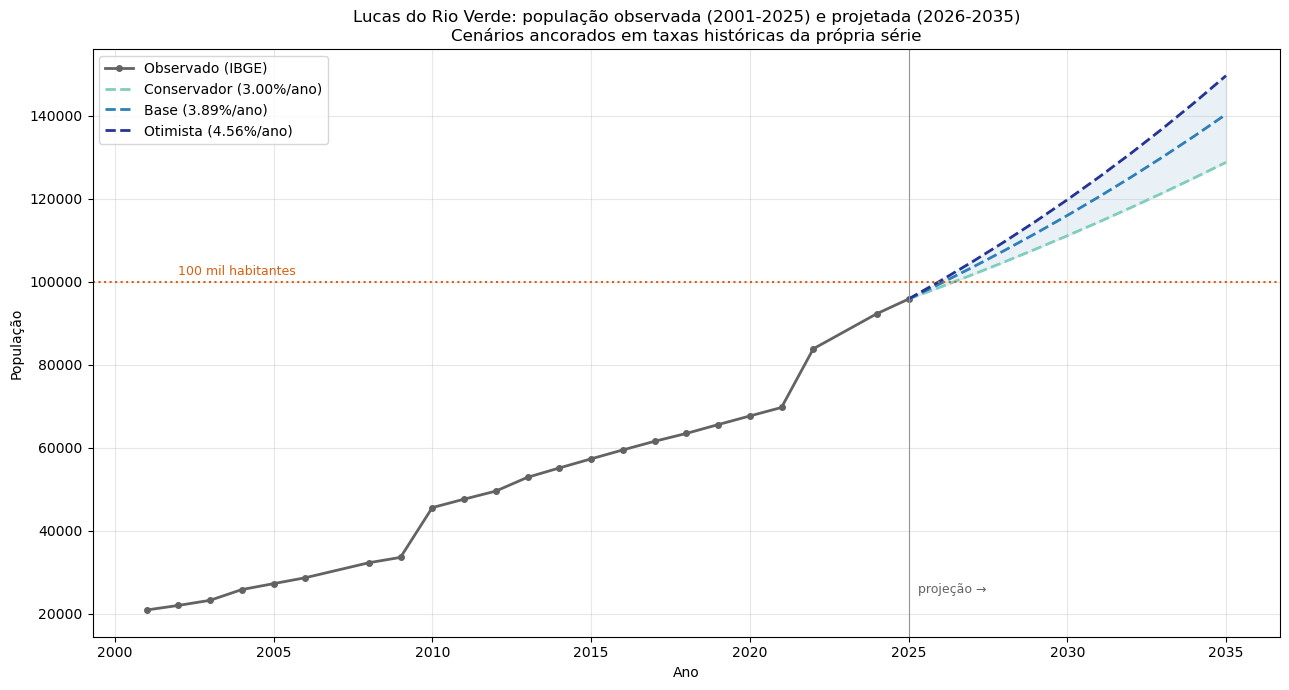

In [9]:
# --- Gráfico: histórico + cenários projetados ---

cores = {'Conservador': '#7fcdbb', 'Base': '#2c7fb8', 'Otimista': '#253494'}

fig, ax = plt.subplots(figsize=(13, 7))

# Histórico observado
ax.plot(serie['ano'], serie['populacao'], color='#636363', linewidth=2,
        marker='o', markersize=4, label='Observado (IBGE)')

# Cenários projetados
for nome, cor in cores.items():
    ax.plot(proj['ano'], proj[nome], color=cor, linewidth=2, linestyle='--',
            label=f'{nome} ({cenarios[nome]:.2f}%/ano)')

# Faixa de incerteza entre extremos
ax.fill_between(proj['ano'], proj['Conservador'], proj['Otimista'],
                color='#2c7fb8', alpha=0.10)

# Marco dos 100 mil habitantes
ax.axhline(100000, color='#d95f0e', linestyle=':', linewidth=1.5)
ax.text(2002, 101500, '100 mil habitantes', color='#d95f0e', fontsize=9)

# Divisor entre observado e projetado
ax.axvline(2025, color='#969696', linestyle='-', linewidth=0.8)
ax.text(2025.3, 25000, 'projeção →', color='#636363', fontsize=9)

ax.set_title('Lucas do Rio Verde: população observada (2001-2025) e projetada (2026-2035)\n'
             'Cenários ancorados em taxas históricas da própria série')
ax.set_xlabel('Ano')
ax.set_ylabel('População')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Fluxo anual de novos moradores

A projeção acumulada responde "quantos habitantes", mas o mercado imobiliário opera por ano. Esta seção converte o estoque projetado no fluxo de chegadas anuais — quantas pessoas novas a cidade absorve a cada ano.

In [10]:
# --- Fluxo anual de novos moradores ---

fluxo = pd.DataFrame({'ano': proj['ano'][1:].values})
for nome in cenarios:
    fluxo[nome] = proj[nome].diff().dropna().astype(int).values

print(fluxo.to_string(index=False))

print('\n--- Chegadas anuais: primeiro e último ano da projeção ---')
for nome in cenarios:
    print(f'{nome:12s}: {fluxo[nome].iloc[0]:,} em 2026  →  {fluxo[nome].iloc[-1]:,} em 2035'.replace(',', '.'))

print('\n--- Total acumulado de novos moradores (2026-2035) ---')
for nome in cenarios:
    print(f'{nome:12s}: {fluxo[nome].sum():,} pessoas'.replace(',', '.'))

 ano  Conservador  Base  Otimista
2026         2874  3726      4368
2027         2960  3872      4567
2028         3049  4021      4776
2029         3140  4179      4993
2030         3234  4341      5221
2031         3332  4509      5459
2032         3431  4685      5709
2033         3534  4868      5968
2034         3641  5056      6240
2035         3749  5254      6525

--- Chegadas anuais: primeiro e último ano da projeção ---
Conservador : 2.874 em 2026  →  3.749 em 2035
Base        : 3.726 em 2026  →  5.254 em 2035
Otimista    : 4.368 em 2026  →  6.525 em 2035

--- Total acumulado de novos moradores (2026-2035) ---
Conservador : 32.944 pessoas
Base        : 44.511 pessoas
Otimista    : 53.826 pessoas


### O efeito de composição

Mesmo com taxa percentual fixa, o número absoluto de chegadas cresce ano a ano, porque a base sobre a qual a taxa incide é maior a cada período. No cenário Base, a cidade sai de 3.726 novos moradores em 2026 para 5.254 em 2035 — o mesmo ritmo percentual, aplicado a uma população maior, gera um fluxo absoluto crescente.

Somando a década, o cenário Base implica **44.511 novos moradores entre 2026 e 2035** — o equivalente a meia cidade atual chegando em dez anos.

## 11. Demanda habitacional

A conversão de pessoas em moradias usa o número médio de moradores por domicílio. Cada contingente anual de novos moradores é dividido por esse parâmetro para estimar quantas unidades habitacionais são necessárias para abrigá-los.

⚠️ **Parâmetro provisório:** `moradores_por_domicilio = 3.0` é uma estimativa de trabalho. O valor definitivo deve vir do Censo 2022 (IBGE Cidades/SIDRA) para o próprio município — a seção seguinte testa o quanto esse parâmetro afeta o resultado.

Nota conceitual: este número é **demanda bruta por novas unidades**, derivada só do crescimento populacional. Não é o déficit habitacional (que inclui coabitação, moradias precárias e ônus excessivo), nem desconta a oferta já em construção. É o piso da pressão por moradia, não o retrato completo.

In [11]:
# --- Conversão: população adicional → demanda por moradias ---

moradores_por_domicilio = 3.0   # PROVISÓRIO — confirmar no Censo 2022

dem = pd.DataFrame({'ano': fluxo['ano']})
for nome in cenarios:
    dem[nome] = (fluxo[nome] / moradores_por_domicilio).round().astype(int)

print(f'Parâmetro: {moradores_por_domicilio} moradores por domicílio\n')
print(dem.to_string(index=False))

print('\n--- Demanda acumulada de novas moradias (2026-2035) ---')
for nome in cenarios:
    total = dem[nome].sum()
    print(f'{nome:12s}: {total:,} unidades  (média de {total/10:,.0f}/ano)'.replace(',', '.'))

Parâmetro: 3.0 moradores por domicílio

 ano  Conservador  Base  Otimista
2026          958  1242      1456
2027          987  1291      1522
2028         1016  1340      1592
2029         1047  1393      1664
2030         1078  1447      1740
2031         1111  1503      1820
2032         1144  1562      1903
2033         1178  1623      1989
2034         1214  1685      2080
2035         1250  1751      2175

--- Demanda acumulada de novas moradias (2026-2035) ---
Conservador : 10.983 unidades  (média de 1.098/ano)
Base        : 14.837 unidades  (média de 1.484/ano)
Otimista    : 17.941 unidades  (média de 1.794/ano)


## 12. Análise de sensibilidade

Duas fontes de incerteza afetam a demanda: qual cenário de crescimento se realiza, e qual o valor real de moradores por domicílio. A matriz cruza os três cenários com três valores do parâmetro para medir o peso relativo de cada fonte.

In [12]:
# --- Análise de sensibilidade: parâmetro × cenário ---

variacoes = [2.8, 3.0, 3.2]

matriz = pd.DataFrame(index=[f'{v} moradores/dom.' for v in variacoes],
                      columns=list(cenarios.keys()), dtype=int)

for v in variacoes:
    for nome in cenarios:
        matriz.loc[f'{v} moradores/dom.', nome] = int((fluxo[nome] / v).round().sum())

matriz = matriz.astype(int)

print('Demanda acumulada de moradias, 2026-2035\n')
print(matriz.to_string())

piso = matriz.values.min()
teto = matriz.values.max()

print(f'\nPiso (mais restritivo):  {piso:,} unidades'.replace(',', '.'))
print(f'Teto (mais expansivo):   {teto:,} unidades'.replace(',', '.'))

# Quanto cada fator move o resultado, isoladamente
efeito_param = matriz.loc['2.8 moradores/dom.', 'Base'] - matriz.loc['3.2 moradores/dom.', 'Base']
efeito_cen   = matriz.loc['3.0 moradores/dom.', 'Otimista'] - matriz.loc['3.0 moradores/dom.', 'Conservador']

print(f'\nEfeito de variar o parâmetro (2.8 → 3.2, cenário Base): {efeito_param:,} unidades'.replace(',', '.'))
print(f'Efeito de variar o cenário (Conserv. → Otim., param. 3.0): {efeito_cen:,} unidades'.replace(',', '.'))
print(f'Razão: o cenário pesa {efeito_cen/efeito_param:.1f}x mais que o parâmetro.')

Demanda acumulada de moradias, 2026-2035

                    Conservador   Base  Otimista
2.8 moradores/dom.        11764  15896     19224
3.0 moradores/dom.        10983  14837     17941
3.2 moradores/dom.        10295  13910     16820

Piso (mais restritivo):  10.295 unidades
Teto (mais expansivo):   19.224 unidades

Efeito de variar o parâmetro (2.8 → 3.2. cenário Base): 1.986 unidades
Efeito de variar o cenário (Conserv. → Otim.. param. 3.0): 6.958 unidades
Razão: o cenário pesa 3.5x mais que o parâmetro.


### Leitura: o cenário pesa mais que o parâmetro

A demanda acumulada 2026–2035 varia de **10.295 unidades** (piso: crescimento conservador com domicílios maiores) a **19.224 unidades** (teto: crescimento otimista com domicílios menores).

O achado que justifica seguir com o parâmetro provisório: variar o **cenário** de crescimento move o resultado em 6.958 unidades, enquanto variar o **parâmetro** de moradores/domicílio move apenas 1.986. **O cenário pesa 3,5× mais que o parâmetro.** A incerteza dominante está no ritmo de crescimento, não na razão domiciliar — então refinar o parâmetro depois, com o Censo 2022, muda pouco a conclusão central.

## 13. Modelagem estatística e validação temporal

Os cenários acima são projeções determinísticas ancoradas em CAGR. Esta seção confronta essa abordagem com dois modelos estatísticos — regressão linear e log-linear — validados por divisão temporal: treina-se no passado e testa-se contra anos recentes já conhecidos, medindo o erro fora da amostra.

O período pré-2011 é deliberadamente excluído para evitar a descontinuidade do rebaseamento de 2010.

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --- Preparação ---
# Usa apenas o período pós-rebaseamento de 2010, para evitar a descontinuidade
dados_modelo = serie[serie['ano'] >= 2011].copy().reset_index(drop=True)

X = dados_modelo[['ano']].values
y = dados_modelo['populacao'].values

# Divisão temporal: treino até 2020, teste de 2021 em diante
corte = 2020
treino = dados_modelo['ano'] <= corte
teste  = dados_modelo['ano'] >  corte

X_treino, y_treino = X[treino], y[treino]
X_teste,  y_teste  = X[teste],  y[teste]

print(f'Treino: {dados_modelo["ano"][treino].min()}-{dados_modelo["ano"][treino].max()} '
      f'({treino.sum()} observações)')
print(f'Teste:  {dados_modelo["ano"][teste].min()}-{dados_modelo["ano"][teste].max()} '
      f'({teste.sum()} observações)')

# --- Modelo 1: Regressão linear (crescimento constante em pessoas/ano) ---
mod_lin = LinearRegression().fit(X_treino, y_treino)
pred_lin = mod_lin.predict(X_teste)

# --- Modelo 2: Regressão log-linear (crescimento constante em %) ---
mod_log = LinearRegression().fit(X_treino, np.log(y_treino))
pred_log = np.exp(mod_log.predict(X_teste))

# --- Avaliação ---
def avaliar(nome, y_real, y_pred):
    mae  = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mape = np.mean(np.abs((y_real - y_pred) / y_real)) * 100
    r2   = r2_score(y_real, y_pred)
    print(f'\n{nome}')
    print(f'  MAE  : {mae:,.0f} pessoas')
    print(f'  RMSE : {rmse:,.0f} pessoas')
    print(f'  MAPE : {mape:.2f}%')
    print(f'  R²   : {r2:.4f}')
    return mae, rmse, mape, r2

print('\n=== Desempenho no conjunto de teste ===')
avaliar('Regressão linear', y_teste, pred_lin)
avaliar('Regressão log-linear (exponencial)', y_teste, pred_log)

# --- Comparação ponto a ponto ---
comp = pd.DataFrame({
    'ano': dados_modelo['ano'][teste].values,
    'real': y_teste,
    'linear': pred_lin.round(0),
    'log_linear': pred_log.round(0)
})
comp['erro_linear'] = (comp['linear'] - comp['real']).astype(int)
comp['erro_log']    = (comp['log_linear'] - comp['real']).astype(int)

print('\n=== Previsto vs. realizado ===')
print(comp.to_string(index=False))

# --- Coeficientes interpretados ---
print(f'\nLinear: {mod_lin.coef_[0]:,.0f} pessoas/ano')
print(f'Log-linear: {(np.exp(mod_log.coef_[0]) - 1) * 100:.2f}% ao ano')

Treino: 2011-2020 (10 observações)
Teste:  2021-2025 (4 observações)

=== Desempenho no conjunto de teste ===

Regressão linear
  MAE  : 10,993 pessoas
  RMSE : 12,694 pessoas
  MAPE : 12.11%
  R²   : -0.5915

Regressão log-linear (exponencial)
  MAE  : 8,969 pessoas
  RMSE : 9,969 pessoas
  MAPE : 10.01%
  R²   : 0.0183

=== Previsto vs. realizado ===
 ano  real  linear  log_linear  erro_linear  erro_log
2021 69671 70209.0     71340.0          538      1669
2022 83798 72432.0     74164.0       -11366     -9634
2024 92256 76879.0     80152.0       -15377    -12104
2025 95792 79102.0     83325.0       -16690    -12467

Linear: 2,223 pessoas/ano
Log-linear: 3.96% ao ano


### Diagnóstico: a quebra estrutural de 2022

Os erros de 2021 são pequenos (abaixo de 2,5%), mas a partir de 2022 os dois modelos passam a **subestimar sistematicamente** a população. A causa não é falha do algoritmo — é o rebaseamento censitário de 2022: os modelos foram treinados até 2020, antes da correção, e não têm como antecipar o salto de nível que o Censo revelou.

O modelo log-linear aprendeu uma taxa de 3,96% ao ano — praticamente idêntica ao CAGR intercensal de 3,89% usado no cenário Base. Dois métodos independentes convergem para o mesmo ritmo, o que reforça a escolha da âncora.

In [14]:
# --- Retreino incorporando o período pós-censo ---

treino2 = dados_modelo['ano'] <= 2024
teste2  = dados_modelo['ano'] == 2025

X_tr2, y_tr2 = X[treino2], y[treino2]
X_te2, y_te2 = X[teste2],  y[teste2]

print(f'Treino: 2011-2024 ({treino2.sum()} obs.) | Teste: 2025 ({teste2.sum()} obs.)')

mod_lin2 = LinearRegression().fit(X_tr2, y_tr2)
mod_log2 = LinearRegression().fit(X_tr2, np.log(y_tr2))

p_lin2 = mod_lin2.predict(X_te2)
p_log2 = np.exp(mod_log2.predict(X_te2))

print(f'\n2025 — real: {y_te2[0]:,.0f}')
print(f'  Linear    : {p_lin2[0]:,.0f}  (erro {p_lin2[0]-y_te2[0]:+,.0f} | '
      f'{(p_lin2[0]-y_te2[0])/y_te2[0]*100:+.2f}%)')
print(f'  Log-linear: {p_log2[0]:,.0f}  (erro {p_log2[0]-y_te2[0]:+,.0f} | '
      f'{(p_log2[0]-y_te2[0])/y_te2[0]*100:+.2f}%)')

print('\nCoeficientes aprendidos:')
print(f'  Linear    : {mod_lin2.coef_[0]:,.0f} pessoas/ano')
print(f'  Log-linear: {(np.exp(mod_log2.coef_[0])-1)*100:.2f}% ao ano')

# Ajuste no próprio treino (não é validação, é diagnóstico de aderência)
print(f'\nR² no treino — linear: {mod_lin2.score(X_tr2, y_tr2):.4f} | '
      f'log-linear: {mod_log2.score(X_tr2, np.log(y_tr2)):.4f}')

Treino: 2011-2024 (13 obs.) | Teste: 2025 (1 obs.)

2025 — real: 95,792
  Linear    : 87,633  (erro -8,159 | -8.52%)
  Log-linear: 90,142  (erro -5,650 | -5.90%)

Coeficientes aprendidos:
  Linear    : 3,045 pessoas/ano
  Log-linear: 4.75% ao ano

R² no treino — linear: 0.9082 | log-linear: 0.9523


### Retreino: incorporando o pós-censo

Ao estender o treino até 2024 — já com o rebaseamento de 2022 dentro da amostra — o modelo log-linear passa a aprender 4,75% ao ano, com R² de 0,95 no treino. Ainda assim subestima 2025: uma única reta de regressão atravessando a quebra estrutural fica abaixo dos pontos mais recentes. A modelagem captura a tendência, mas nenhum modelo de linha única reproduz perfeitamente uma série com dois rebaseamentos.

## 14. Projeção comparativa para 2035

Colocando lado a lado todos os métodos — os dois modelos estatísticos e os três cenários de CAGR — para verificar se convergem ou divergem no horizonte de 2035.

In [15]:
# --- Projeção dos modelos até 2035 e confronto com os cenários ---

anos_fut = np.array(range(2026, 2036)).reshape(-1, 1)

proj_lin = mod_lin2.predict(anos_fut)
proj_log = np.exp(mod_log2.predict(anos_fut))

comp_2035 = pd.DataFrame({
    'metodo': ['Regressão linear', 'Regressão log-linear',
               'Cenário Conservador', 'Cenário Base', 'Cenário Otimista'],
    'taxa': [f'{mod_lin2.coef_[0]:,.0f} pessoas/ano',
             f'{(np.exp(mod_log2.coef_[0])-1)*100:.2f}% ao ano',
             f'{cenarios["Conservador"]:.2f}% ao ano',
             f'{cenarios["Base"]:.2f}% ao ano',
             f'{cenarios["Otimista"]:.2f}% ao ano'],
    'pop_2035': [round(proj_lin[-1]),
                 round(proj_log[-1]),
                 proj.loc[proj['ano'] == 2035, 'Conservador'].iloc[0],
                 proj.loc[proj['ano'] == 2035, 'Base'].iloc[0],
                 proj.loc[proj['ano'] == 2035, 'Otimista'].iloc[0]]
})

print('Projeções para 2035 por método\n')
print(comp_2035.to_string(index=False))

dif = abs(round(proj_log[-1]) - proj.loc[proj['ano'] == 2035, 'Base'].iloc[0])
print(f'\nDiferença entre log-linear e cenário Base em 2035: {dif:,} pessoas '
      f'({dif/proj.loc[proj["ano"] == 2035, "Base"].iloc[0]*100:.1f}%)'.replace(',', '.'))

Projeções para 2035 por método

              metodo              taxa  pop_2035
    Regressão linear 3,045 pessoas/ano    118087
Regressão log-linear      4.75% ao ano    143401
 Cenário Conservador      3.00% ao ano    128736
        Cenário Base      3.89% ao ano    140303
    Cenário Otimista      4.56% ao ano    149618

Diferença entre log-linear e cenário Base em 2035: 3.098 pessoas (2.2%)


### A convergência de dois métodos independentes

O resultado mais forte da análise: a regressão log-linear projeta **143.401** habitantes em 2035, e o cenário Base (CAGR) projeta **140.303**. A diferença é de 3.098 pessoas — apenas **2,2% ao longo de dez anos**.

São dois caminhos metodologicamente distintos: um ajusta uma reta aos logaritmos de toda a série recente; o outro aplica uma taxa composta fixa derivada só do período intercensal limpo. Que ambos cheguem essencialmente ao mesmo número não é coincidência forçada — é convergência independente, e é o que dá confiança à projeção central.

## 15. Limitações

1. **Parâmetro domiciliar provisório.** `moradores_por_domicilio = 3.0` ainda não foi confirmado no Censo 2022 para o município. A análise de sensibilidade mostra que o impacto é secundário (3,5× menor que o cenário), mas o valor definitivo deve substituí-lo.
2. **Demanda bruta, não déficit.** Os números refletem apenas moradia gerada por crescimento populacional. Não incluem déficit acumulado (coabitação, precariedade) nem descontam a oferta já em construção.
3. **Anos ausentes não interpolados.** 2007 e 2023 permanecem fora da série. As taxas contornam isso normalizando pelo tempo, mas a série observada tem buracos reais.
4. **Projeção por taxa constante.** Os cenários supõem ritmo percentual fixo até 2035. Choques econômicos locais (expansão ou retração do agronegócio) podem alterar a trajetória de forma que nenhum modelo de tendência captura.
5. **Modelo de linha única sobre série com quebras.** As regressões não modelam explicitamente os rebaseamentos censitários, o que gera subestimação sistemática pós-2022.
6. **Sem segmentação de mercado.** A demanda é tratada como agregada. Não distingue faixa de renda, tipologia (casa/apartamento) nem faixa de preço — refinamentos previstos para camadas futuras do projeto.

## 16. Síntese executiva

**Lucas do Rio Verde deve cruzar 100 mil habitantes até 2027** em qualquer cenário de crescimento razoável — o mais tímido dos três já leva a cidade a esse patamar. No horizonte de 2035, a população projetada fica entre **128.736** (Conservador) e **149.618** (Otimista), com o cenário central em torno de **140.000**.

Esse crescimento se traduz em **demanda por novas moradias**: entre 2026 e 2035, a cidade precisará de algo entre **10.300 e 19.200 unidades habitacionais** só para abrigar os novos moradores — uma média de aproximadamente **1.100 a 1.800 unidades por ano**. O cenário central (Base, 3,0 moradores/domicílio) aponta cerca de **14.800 unidades na década**.

A confiança na projeção central vem de dois métodos independentes — CAGR intercensal e regressão log-linear — que convergem para praticamente o mesmo número em 2035, com diferença de apenas 2,2%.

Para o setor imobiliário e a construção civil locais, a leitura é direta: a pressão por moradia não é hipótese, é tendência ancorada em três décadas de dados. O número aqui é o piso — demanda bruta por crescimento, sem contar déficit acumulado nem reposição.